In [ ]:
from google.colab import files
import zipfile
import os
import json

# Upload the new IPL dataset
uploaded = files.upload()

# Get uploaded ZIP filename automatically
ipl_zip = next(
    filename for filename in uploaded
    if filename.lower().endswith(".zip")
)

print("Uploaded file:", ipl_zip)

# Extract dataset
ipl_extract_dir = "/content/ipl_dataset"

os.makedirs(ipl_extract_dir, exist_ok=True)

with zipfile.ZipFile(ipl_zip, "r") as zip_ref:
    zip_ref.extractall(ipl_extract_dir)

# Find JSON files, including files inside subfolders
ipl_json_files = []

for root, dirs, files_list in os.walk(ipl_extract_dir):
    for filename in files_list:
        if filename.lower().endswith(".json"):
            ipl_json_files.append(
                os.path.join(root, filename)
            )

print("JSON match files:", len(ipl_json_files))
print("Dataset folder:", ipl_extract_dir)

# Inspect first match
with open(ipl_json_files[0], "r") as f:
    sample_ipl = json.load(f)

print("\nSample match loaded successfully.")
print("Top-level keys:", sample_ipl.keys())

Saving ipl_male_json.zip to ipl_male_json (1).zip
Uploaded file: ipl_male_json (1).zip
JSON match files: 1243
Dataset folder: /content/ipl_dataset

Sample match loaded successfully.
Top-level keys: dict_keys(['meta', 'info', 'innings'])


In [ ]:
print("META")
print("=" * 50)
print(sample_ipl.get("meta"))

print("\nINFO KEYS")
print("=" * 50)
print(sample_ipl["info"].keys())

print("\nTEAMS")
print("=" * 50)
print(sample_ipl["info"].get("teams"))

print("\nDATES")
print("=" * 50)
print(sample_ipl["info"].get("dates"))

print("\nVENUE")
print("=" * 50)
print(sample_ipl["info"].get("venue"))

print("\nCITY")
print("=" * 50)
print(sample_ipl["info"].get("city"))

print("\nTOSS")
print("=" * 50)
print(sample_ipl["info"].get("toss"))

print("\nOUTCOME")
print("=" * 50)
print(sample_ipl["info"].get("outcome"))

META
{'data_version': '1.2.0', 'created': '2011-05-06', 'revision': 2}

INFO KEYS
dict_keys(['balls_per_over', 'city', 'dates', 'event', 'gender', 'match_type', 'officials', 'outcome', 'overs', 'player_of_match', 'players', 'registry', 'season', 'team_type', 'teams', 'toss', 'venue'])

TEAMS
['Mumbai Indians', 'Deccan Chargers']

DATES
['2008-04-27']

VENUE
Dr DY Patil Sports Academy

CITY
Mumbai

TOSS
{'decision': 'field', 'winner': 'Deccan Chargers'}

OUTCOME
{'by': {'wickets': 10}, 'winner': 'Deccan Chargers'}


In [ ]:
print("META")
print("=" * 50)
print(sample_ipl.get("meta"))

print("\nINFO KEYS")
print("=" * 50)
print(sample_ipl["info"].keys())

print("\nTEAMS")
print("=" * 50)
print(sample_ipl["info"].get("teams"))

print("\nDATES")
print("=" * 50)
print(sample_ipl["info"].get("dates"))

print("\nVENUE")
print("=" * 50)
print(sample_ipl["info"].get("venue"))

print("\nCITY")
print("=" * 50)
print(sample_ipl["info"].get("city"))

print("\nTOSS")
print("=" * 50)
print(sample_ipl["info"].get("toss"))

print("\nOUTCOME")
print("=" * 50)
print(sample_ipl["info"].get("outcome"))

META
{'data_version': '1.2.0', 'created': '2011-05-06', 'revision': 2}

INFO KEYS
dict_keys(['balls_per_over', 'city', 'dates', 'event', 'gender', 'match_type', 'officials', 'outcome', 'overs', 'player_of_match', 'players', 'registry', 'season', 'team_type', 'teams', 'toss', 'venue'])

TEAMS
['Mumbai Indians', 'Deccan Chargers']

DATES
['2008-04-27']

VENUE
Dr DY Patil Sports Academy

CITY
Mumbai

TOSS
{'decision': 'field', 'winner': 'Deccan Chargers'}

OUTCOME
{'by': {'wickets': 10}, 'winner': 'Deccan Chargers'}


In [ ]:
ipl_teams = set()
ipl_seasons = set()

for file in ipl_json_files:
    with open(file, "r") as f:
        match = json.load(f)

    info = match["info"]

    for team in info.get("teams", []):
        ipl_teams.add(team)

    if "season" in info:
        ipl_seasons.add(str(info["season"]))

print("Number of teams:", len(ipl_teams))
print("\nTeams:")
for team in sorted(ipl_teams):
    print("-", team)

print("\nNumber of seasons:", len(ipl_seasons))
print("Seasons:")
print(sorted(ipl_seasons))

Number of teams: 19

Teams:
- Chennai Super Kings
- Deccan Chargers
- Delhi Capitals
- Delhi Daredevils
- Gujarat Lions
- Gujarat Titans
- Kings XI Punjab
- Kochi Tuskers Kerala
- Kolkata Knight Riders
- Lucknow Super Giants
- Mumbai Indians
- Pune Warriors
- Punjab Kings
- Rajasthan Royals
- Rising Pune Supergiant
- Rising Pune Supergiants
- Royal Challengers Bangalore
- Royal Challengers Bengaluru
- Sunrisers Hyderabad

Number of seasons: 19
Seasons:
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']


In [ ]:
import pandas as pd
import os
import json

ipl_performance = []

for file in ipl_json_files:

    with open(file, "r") as f:
        match = json.load(f)

    info = match["info"]
    teams = info.get("teams", [])

    if len(teams) != 2:
        continue

    dates = info.get("dates", [])

    match_date = pd.to_datetime(
        str(dates[0]) if dates else None,
        errors="coerce"
    )

    match_id = os.path.basename(file).replace(".json", "")

    for innings in match.get("innings", []):

        batting_team = innings.get("team")

        if batting_team not in teams:
            continue

        total_runs = 0
        total_balls = 0
        wickets_lost = 0

        for over in innings.get("overs", []):

            for delivery in over.get("deliveries", []):

                runs = delivery.get("runs", {})

                total_runs += runs.get("total", 0)

                extras = delivery.get("extras", {})

                # Legal delivery
                if "wides" not in extras and "noballs" not in extras:
                    total_balls += 1

                # Count wickets
                for wicket in delivery.get("wickets", []):

                    wicket_kind = wicket.get(
                        "kind", ""
                    ).lower()

                    if wicket_kind != "retired hurt":
                        wickets_lost += 1

        # Run rate
        run_rate = (
            total_runs / (total_balls / 6)
            if total_balls > 0
            else 0
        )

        ipl_performance.append({
            "match_id": match_id,
            "date": match_date,
            "team": batting_team,
            "runs": total_runs,
            "wickets_lost": wickets_lost,
            "balls": total_balls,
            "run_rate": run_rate
        })

ipl_performance = pd.DataFrame(ipl_performance)

print("IPL innings records:", len(ipl_performance))
print("\nColumns:")
print(ipl_performance.columns.tolist())

display(ipl_performance.head())

IPL innings records: 2514

Columns:
['match_id', 'date', 'team', 'runs', 'wickets_lost', 'balls', 'run_rate']


,match_id,date,team,runs,wickets_lost,balls,run_rate
0,335994,2008-04-27,Mumbai Indians,154,7,120,7.700000
1,335994,2008-04-27,Deccan Chargers,155,0,73,12.739726
2,1082633,2017-05-05,Kings XI Punjab,138,7,120,6.900000
3,1082633,2017-05-05,Royal Challengers Bangalore,119,10,114,6.263158
4,1136570,2018-04-14,Kolkata Knight Riders,138,8,120,6.900000


In [ ]:
print("IPL INNINGS DATA VALIDATION")
print("=" * 50)

print("Innings records:", len(ipl_performance))
print("Missing runs:", ipl_performance["runs"].isna().sum())
print("Missing wickets:", ipl_performance["wickets_lost"].isna().sum())
print("Missing balls:", ipl_performance["balls"].isna().sum())
print("Missing run rates:", ipl_performance["run_rate"].isna().sum())

print("\nRuns statistics:")
print(ipl_performance["runs"].describe())

print("\nWickets statistics:")
print(ipl_performance["wickets_lost"].describe())

print("\nRun-rate statistics:")
print(ipl_performance["run_rate"].describe())

IPL INNINGS DATA VALIDATION
Innings records: 2514
Missing runs: 0
Missing wickets: 0
Missing balls: 0
Missing run rates: 0

Runs statistics:
count    2514.000000
mean      159.800318
std        38.463919
min         1.000000
25%       139.250000
50%       161.000000
75%       183.750000
max       287.000000
Name: runs, dtype: float64

Wickets statistics:
count    2514.000000
mean        5.841687
std         2.515609
min         0.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: wickets_lost, dtype: float64

Run-rate statistics:
count    2514.000000
mean        8.529945
std         1.809603
min         1.714286
25%         7.350000
50%         8.400000
75%         9.531886
max        27.000000
Name: run_rate, dtype: float64


In [ ]:
import pandas as pd
import json
import os

print("Preparing IPL match dataset...")
print("=" * 50)

# Rebuild ipl_matches if it does not exist
if "ipl_matches" not in globals():

    print("ipl_matches not found. Rebuilding it...")

    ipl_match_records = []

    for file in ipl_json_files:

        with open(file, "r") as f:
            match = json.load(f)

        info = match.get("info", {})
        teams = info.get("teams", [])

        if len(teams) != 2:
            continue

        team1 = teams[0]
        team2 = teams[1]

        outcome = info.get("outcome", {})
        winner = outcome.get("winner")

        if winner not in teams:
            continue

        toss = info.get("toss", {})
        dates = info.get("dates", [])

        ipl_match_records.append({
            "match_id": os.path.basename(file).replace(".json", ""),
            "date": str(dates[0]) if dates else None,
            "season": str(info.get("season")),
            "team_1": team1,
            "team_2": team2,
            "venue": info.get("venue", "Unknown"),
            "city": info.get("city", "Unknown"),
            "toss_winner": toss.get("winner"),
            "toss_decision": toss.get("decision"),
            "winner": winner,
            "target": 1 if winner == team1 else 0
        })

    ipl_matches = pd.DataFrame(ipl_match_records)

    ipl_matches["date"] = pd.to_datetime(
        ipl_matches["date"],
        errors="coerce"
    )

    ipl_matches = (
        ipl_matches
        .sort_values("date")
        .reset_index(drop=True)
    )

else:
    print("ipl_matches already exists.")

print("\nIPL MATCH DATA READY")
print("Total matches:", len(ipl_matches))
print("Columns:", len(ipl_matches.columns))

display(ipl_matches.head())

Preparing IPL match dataset...
ipl_matches not found. Rebuilding it...

IPL MATCH DATA READY
Total matches: 1218
Columns: 11


,match_id,date,season,team_1,team_2,venue,city,toss_winner,toss_decision,winner,target
0,335982,2008-04-18,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,0
1,335984,2008-04-19,2007/08,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Delhi,Rajasthan Royals,bat,Delhi Daredevils,1
2,335983,2008-04-19,2007/08,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,bat,Chennai Super Kings,0
3,335985,2008-04-20,2007/08,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai,Mumbai Indians,bat,Royal Challengers Bangalore,0
4,335986,2008-04-20,2007/08,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Kolkata,Deccan Chargers,bat,Kolkata Knight Riders,1


In [ ]:
print("IPL MATCH DATA VALIDATION")
print("=" * 50)

print("Total matches:", len(ipl_matches))
print("Missing dates:", ipl_matches["date"].isna().sum())
print("Missing teams:", (
    ipl_matches["team_1"].isna().sum()
    + ipl_matches["team_2"].isna().sum()
))
print("Missing venues:", ipl_matches["venue"].isna().sum())
print("Missing toss winners:", ipl_matches["toss_winner"].isna().sum())
print("Missing winners:", ipl_matches["winner"].isna().sum())

print("\nTarget distribution:")
print(ipl_matches["target"].value_counts())

print("\nSeasons:")
print(
    ipl_matches["season"]
    .value_counts()
    .sort_index()
)

IPL MATCH DATA VALIDATION
Total matches: 1218
Missing dates: 0
Missing teams: 0
Missing venues: 0
Missing toss winners: 0
Missing winners: 0

Target distribution:
target
0    610
1    608
Name: count, dtype: int64

Seasons:
season
2007/08    58
2009       56
2009/10    59
2011       72
2012       74
2013       74
2014       59
2015       56
2016       60
2017       58
2018       60
2019       57
2020/21    56
2021       59
2022       74
2023       73
2024       71
2025       70
2026       72
Name: count, dtype: int64


In [ ]:
ipl_performance = []

for file in ipl_json_files:

    with open(file, "r") as f:
        match = json.load(f)

    info = match.get("info", {})
    teams = info.get("teams", [])

    if len(teams) != 2:
        continue

    outcome = info.get("outcome", {})
    winner = outcome.get("winner")

    if winner not in teams:
        continue

    dates = info.get("dates", [])
    match_id = os.path.basename(file).replace(".json", "")

    match_date = pd.to_datetime(
        str(dates[0]) if dates else None,
        errors="coerce"
    )

    for innings in match.get("innings", []):

        batting_team = innings.get("team")

        if batting_team not in teams:
            continue

        total_runs = 0
        total_balls = 0
        wickets_lost = 0

        for over in innings.get("overs", []):

            for delivery in over.get("deliveries", []):

                runs = delivery.get("runs", {})
                total_runs += runs.get("total", 0)

                extras = delivery.get("extras", {})

                if (
                    "wides" not in extras
                    and "noballs" not in extras
                ):
                    total_balls += 1

                for wicket in delivery.get("wickets", []):

                    kind = str(
                        wicket.get("kind", "")
                    ).lower()

                    if kind != "retired hurt":
                        wickets_lost += 1

        run_rate = (
            total_runs / (total_balls / 6)
            if total_balls > 0
            else 0
        )

        ipl_performance.append({
            "match_id": match_id,
            "date": match_date,
            "team": batting_team,
            "runs": total_runs,
            "wickets_lost": wickets_lost,
            "balls": total_balls,
            "run_rate": run_rate
        })

ipl_performance = pd.DataFrame(ipl_performance)

print("IPL innings data ready.")
print("Innings records:", len(ipl_performance))

display(ipl_performance.head())

IPL innings data ready.
Innings records: 2436


,match_id,date,team,runs,wickets_lost,balls,run_rate
0,335994,2008-04-27,Mumbai Indians,154,7,120,7.700000
1,335994,2008-04-27,Deccan Chargers,155,0,73,12.739726
2,1082633,2017-05-05,Kings XI Punjab,138,7,120,6.900000
3,1082633,2017-05-05,Royal Challengers Bangalore,119,10,114,6.263158
4,1136570,2018-04-14,Kolkata Knight Riders,138,8,120,6.900000


In [ ]:
from collections import defaultdict

ipl_team_history = defaultdict(lambda: {
    "matches": 0,
    "wins": 0,
    "runs": [],
    "wickets": [],
    "run_rates": [],
    "recent_results": []
})

ipl_historical_stats = []

for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    s1 = ipl_team_history[team1]
    s2 = ipl_team_history[team2]

    def stats(s):

        matches = s["matches"]

        win_rate = (
            s["wins"] / matches
            if matches > 0 else 0.5
        )

        recent = s["recent_results"][-5:]

        recent_form = (
            sum(recent) / len(recent)
            if recent else 0.5
        )

        avg_runs = (
            sum(s["runs"]) / len(s["runs"])
            if s["runs"] else 0
        )

        avg_wickets = (
            sum(s["wickets"]) / len(s["wickets"])
            if s["wickets"] else 0
        )

        run_rate = (
            sum(s["run_rates"]) / len(s["run_rates"])
            if s["run_rates"] else 0
        )

        return (
            win_rate,
            recent_form,
            avg_runs,
            avg_wickets,
            run_rate
        )

    a = stats(s1)
    b = stats(s2)

    ipl_historical_stats.append({
        "match_id": match["match_id"],
        "team_1": team1,
        "team_2": team2,
        "win_rate_diff": a[0] - b[0],
        "recent_form_diff": a[1] - b[1],
        "avg_runs_diff": a[2] - b[2],
        "avg_wickets_diff": a[3] - b[3],
        "run_rate_diff": a[4] - b[4]
    })

    # Update only AFTER feature calculation
    winner = match["winner"]

    perf = ipl_performance[
        ipl_performance["match_id"]
        == match["match_id"]
    ]

    for team in [team1, team2]:

        team_perf = perf[
            perf["team"] == team
        ]

        if not team_perf.empty:

            ipl_team_history[team]["runs"].append(
                team_perf["runs"].sum()
            )

            ipl_team_history[team]["wickets"].append(
                team_perf["wickets_lost"].sum()
            )

            ipl_team_history[team]["run_rates"].append(
                team_perf["run_rate"].mean()
            )

        ipl_team_history[team]["matches"] += 1

        if winner == team:
            ipl_team_history[team]["wins"] += 1
            ipl_team_history[team]["recent_results"].append(1)
        else:
            ipl_team_history[team]["recent_results"].append(0)

ipl_historical_stats = pd.DataFrame(
    ipl_historical_stats
)

print("Historical statistics created.")
print("Rows:", len(ipl_historical_stats))

display(ipl_historical_stats.head())

Historical statistics created.
Rows: 1218


,match_id,team_1,team_2,win_rate_diff,recent_form_diff,avg_runs_diff,avg_wickets_diff,run_rate_diff
0,335982,Royal Challengers Bangalore,Kolkata Knight Riders,0.0,0.0,0.0,0.0,0.000000
1,335984,Delhi Daredevils,Rajasthan Royals,0.0,0.0,0.0,0.0,0.000000
2,335983,Kings XI Punjab,Chennai Super Kings,0.0,0.0,0.0,0.0,0.000000
3,335985,Mumbai Indians,Royal Challengers Bangalore,0.5,0.5,-82.0,-10.0,-5.406593
4,335986,Kolkata Knight Riders,Deccan Chargers,0.5,0.5,222.0,3.0,11.100000


In [ ]:
ipl_elo = defaultdict(lambda: 1500)
ipl_elo_records = []

K = 20

for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    rating1 = ipl_elo[team1]
    rating2 = ipl_elo[team2]

    ipl_elo_records.append({
        "match_id": match["match_id"],
        "elo_diff": rating1 - rating2
    })

    expected1 = 1 / (
        1 + 10 ** ((rating2 - rating1) / 400)
    )

    actual1 = (
        1
        if match["winner"] == team1
        else 0
    )

    ipl_elo[team1] = (
        rating1 + K * (actual1 - expected1)
    )

    ipl_elo[team2] = (
        rating2 + K * (
            (1 - actual1) - (1 - expected1)
        )
    )

ipl_elo_records = pd.DataFrame(
    ipl_elo_records
)

print("Elo calculation completed.")
print("Records:", len(ipl_elo_records))

display(ipl_elo_records.head())

Elo calculation completed.
Records: 1218


,match_id,elo_diff
0,335982,0.0
1,335984,0.0
2,335983,0.0
3,335985,10.0
4,335986,10.0


In [ ]:
ipl_h2h_history = defaultdict(
    lambda: {
        "matches": 0,
        "team1_wins": 0
    }
)

ipl_h2h_records = []

for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    key = (team1, team2)

    h = ipl_h2h_history[key]

    h2h_rate = (
        h["team1_wins"] / h["matches"]
        if h["matches"] > 0
        else 0.5
    )

    ipl_h2h_records.append({
        "match_id": match["match_id"],
        "team_1_h2h_win_rate": h2h_rate
    })

    h["matches"] += 1

    if match["winner"] == team1:
        h["team1_wins"] += 1

ipl_h2h_records = pd.DataFrame(
    ipl_h2h_records
)

print("H2H calculation completed.")
print("Records:", len(ipl_h2h_records))

display(ipl_h2h_records.head())

H2H calculation completed.
Records: 1218


,match_id,team_1_h2h_win_rate
0,335982,0.5
1,335984,0.5
2,335983,0.5
3,335985,0.5
4,335986,0.5


In [ ]:
# ---------- VENUE ----------

ipl_venue_history = defaultdict(
    lambda: {
        "matches": 0,
        "wins": 0
    }
)

ipl_venue_records = []

for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]
    venue = match["venue"]

    v1 = ipl_venue_history[(team1, venue)]
    v2 = ipl_venue_history[(team2, venue)]

    rate1 = (
        v1["wins"] / v1["matches"]
        if v1["matches"] > 0
        else 0.5
    )

    rate2 = (
        v2["wins"] / v2["matches"]
        if v2["matches"] > 0
        else 0.5
    )

    ipl_venue_records.append({
        "match_id": match["match_id"],
        "venue_win_rate_diff": rate1 - rate2
    })

    v1["matches"] += 1
    v2["matches"] += 1

    if match["winner"] == team1:
        v1["wins"] += 1
    else:
        v2["wins"] += 1

ipl_venue_records = pd.DataFrame(
    ipl_venue_records
)


# ---------- TOSS ----------

def get_toss_features(row):

    if row["toss_winner"] == row["team_1"]:
        toss_diff = 1
    elif row["toss_winner"] == row["team_2"]:
        toss_diff = -1
    else:
        toss_diff = 0

    decision = str(
        row["toss_decision"]
    ).lower()

    if row["toss_winner"] == row["team_1"]:
        bat_first_diff = (
            1 if decision == "bat" else -1
        )

    elif row["toss_winner"] == row["team_2"]:
        bat_first_diff = (
            -1 if decision == "bat" else 1
        )

    else:
        bat_first_diff = 0

    return toss_diff, bat_first_diff


toss_values = ipl_matches.apply(
    get_toss_features,
    axis=1
)

ipl_matches["toss_winner_diff"] = [
    x[0] for x in toss_values
]

ipl_matches["bat_first_diff"] = [
    x[1] for x in toss_values
]

print("Venue + Toss features created.")

Venue + Toss features created.


In [ ]:
# Start with the basic match information
ipl_model_data = ipl_matches[
    [
        "match_id",
        "date",
        "season",
        "team_1",
        "team_2",
        "venue",
        "toss_winner",
        "toss_decision",
        "target"
    ]
].copy()

# Merge historical team statistics
ipl_model_data = ipl_model_data.merge(
    ipl_historical_stats,
    on=["match_id", "team_1", "team_2"],
    how="left"
)

# Merge Elo
ipl_model_data = ipl_model_data.merge(
    ipl_elo_records,
    on="match_id",
    how="left"
)

# Merge H2H
ipl_model_data = ipl_model_data.merge(
    ipl_h2h_records,
    on="match_id",
    how="left"
)

# Merge venue
ipl_model_data = ipl_model_data.merge(
    ipl_venue_records,
    on="match_id",
    how="left"
)

# Add toss features by match_id
toss_data = ipl_matches[
    [
        "match_id",
        "toss_winner_diff",
        "bat_first_diff"
    ]
].copy()

ipl_model_data = ipl_model_data.merge(
    toss_data,
    on="match_id",
    how="left"
)

print("IPL MODEL DATA CREATED")
print("=" * 50)
print("Rows:", len(ipl_model_data))
print("Columns:", len(ipl_model_data.columns))

display(ipl_model_data.head())

IPL MODEL DATA CREATED
Rows: 1218
Columns: 19


,match_id,date,season,team_1,team_2,venue,toss_winner,toss_decision,target,win_rate_diff,recent_form_diff,avg_runs_diff,avg_wickets_diff,run_rate_diff,elo_diff,team_1_h2h_win_rate,venue_win_rate_diff,toss_winner_diff,bat_first_diff
0,335982,2008-04-18,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,0,0.0,0.0,0.0,0.0,0.000000,0.0,0.5,0.0,1,-1
1,335984,2008-04-19,2007/08,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,1,0.0,0.0,0.0,0.0,0.000000,0.0,0.5,0.0,-1,-1
2,335983,2008-04-19,2007/08,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,0,0.0,0.0,0.0,0.0,0.000000,0.0,0.5,0.0,-1,-1
3,335985,2008-04-20,2007/08,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,0,0.5,0.5,-82.0,-10.0,-5.406593,10.0,0.5,0.0,1,1
4,335986,2008-04-20,2007/08,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,1,0.5,0.5,222.0,3.0,11.100000,10.0,0.5,0.0,-1,-1


In [ ]:
ipl_final_features = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate",
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

X_ipl = ipl_model_data[ipl_final_features].copy()
y_ipl = ipl_model_data["target"].copy()

print("FINAL IPL FEATURES")
print("=" * 50)

for i, feature in enumerate(ipl_final_features, 1):
    print(f"{i}. {feature}")

print("\nX shape:", X_ipl.shape)
print("y shape:", y_ipl.shape)

FINAL IPL FEATURES
1. elo_diff
2. win_rate_diff
3. recent_form_diff
4. avg_runs_diff
5. avg_wickets_diff
6. run_rate_diff
7. team_1_h2h_win_rate
8. venue_win_rate_diff
9. toss_winner_diff
10. bat_first_diff

X shape: (1218, 10)
y shape: (1218,)


In [ ]:
print("IPL FEATURE VALIDATION")
print("=" * 50)

missing = X_ipl.isna().sum()

print("Missing values:")
print(missing)

print("\nTotal missing values:", missing.sum())

print("\nTarget distribution:")
print(y_ipl.value_counts())

if missing.sum() == 0:
    print("\n✓ No missing feature values.")
else:
    print("\n⚠ Missing values found — we'll handle them before training.")

IPL FEATURE VALIDATION
Missing values:
elo_diff               0
win_rate_diff          0
recent_form_diff       0
avg_runs_diff          0
avg_wickets_diff       0
run_rate_diff          0
team_1_h2h_win_rate    0
venue_win_rate_diff    0
toss_winner_diff       0
bat_first_diff         0
dtype: int64

Total missing values: 0

Target distribution:
target
0    610
1    608
Name: count, dtype: int64

✓ No missing feature values.


In [ ]:
n = len(ipl_model_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_ipl_train = X_ipl.iloc[:train_end].copy()
X_ipl_val = X_ipl.iloc[train_end:val_end].copy()
X_ipl_test = X_ipl.iloc[val_end:].copy()

y_ipl_train = y_ipl.iloc[:train_end].copy()
y_ipl_val = y_ipl.iloc[train_end:val_end].copy()
y_ipl_test = y_ipl.iloc[val_end:].copy()

print("IPL CHRONOLOGICAL SPLIT")
print("=" * 50)

print("Total:", n)

print("\nTraining:")
print("Rows:", len(X_ipl_train))
print("Date:", ipl_model_data.iloc[0]["date"],
      "to",
      ipl_model_data.iloc[train_end - 1]["date"])

print("\nValidation:")
print("Rows:", len(X_ipl_val))
print("Date:", ipl_model_data.iloc[train_end]["date"],
      "to",
      ipl_model_data.iloc[val_end - 1]["date"])

print("\nTest:")
print("Rows:", len(X_ipl_test))
print("Date:", ipl_model_data.iloc[val_end]["date"],
      "to",
      ipl_model_data.iloc[-1]["date"])

IPL CHRONOLOGICAL SPLIT
Total: 1218

Training:
Rows: 852
Date: 2008-04-18 00:00:00 to 2021-10-07 00:00:00

Validation:
Rows: 183
Date: 2021-10-08 00:00:00 to 2024-04-15 00:00:00

Test:
Rows: 183
Date: 2024-04-16 00:00:00 to 2026-05-31 00:00:00


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_ipl = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_ipl.fit(
    X_ipl_train,
    y_ipl_train
)

lr_ipl_pred = lr_ipl.predict(X_ipl_test)

lr_ipl_proba = lr_ipl.predict_proba(
    X_ipl_test
)

print("✓ IPL Logistic Regression trained.")
print("Test predictions:", len(lr_ipl_pred))

✓ IPL Logistic Regression trained.
Test predictions: 183


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_ipl = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_ipl.fit(
    X_ipl_train,
    y_ipl_train
)

rf_ipl_pred = rf_ipl.predict(
    X_ipl_test
)

rf_ipl_proba = rf_ipl.predict_proba(
    X_ipl_test
)

print("✓ IPL Random Forest trained.")
print("Test predictions:", len(rf_ipl_pred))

✓ IPL Random Forest trained.
Test predictions: 183


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

lr_ipl_accuracy = accuracy_score(
    y_ipl_test,
    lr_ipl_pred
)

lr_ipl_f1 = f1_score(
    y_ipl_test,
    lr_ipl_pred
)

lr_ipl_auc = roc_auc_score(
    y_ipl_test,
    lr_ipl_proba[:, 1]
)

print("IPL LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy : {lr_ipl_accuracy * 100:.2f}%")
print(f"F1 Score : {lr_ipl_f1 * 100:.2f}%")
print(f"ROC-AUC  : {lr_ipl_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_ipl_test,
        lr_ipl_pred
    )
)

IPL LOGISTIC REGRESSION
Accuracy : 50.27%
F1 Score : 19.47%
ROC-AUC  : 0.3559

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.79      0.64       103
           1       0.33      0.14      0.19        80

    accuracy                           0.50       183
   macro avg       0.44      0.46      0.42       183
weighted avg       0.45      0.50      0.45       183



In [ ]:
rf_ipl_accuracy = accuracy_score(
    y_ipl_test,
    rf_ipl_pred
)

rf_ipl_f1 = f1_score(
    y_ipl_test,
    rf_ipl_pred
)

rf_ipl_auc = roc_auc_score(
    y_ipl_test,
    rf_ipl_proba[:, 1]
)

print("IPL RANDOM FOREST")
print("=" * 50)
print(f"Accuracy : {rf_ipl_accuracy * 100:.2f}%")
print(f"F1 Score : {rf_ipl_f1 * 100:.2f}%")
print(f"ROC-AUC  : {rf_ipl_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_ipl_test,
        rf_ipl_pred
    )
)

IPL RANDOM FOREST
Accuracy : 51.37%
F1 Score : 29.92%
ROC-AUC  : 0.4775

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.73      0.63       103
           1       0.40      0.24      0.30        80

    accuracy                           0.51       183
   macro avg       0.48      0.48      0.46       183
weighted avg       0.49      0.51      0.48       183



In [ ]:
print("MATCHAI IPL MODEL COMPARISON")
print("=" * 70)

print(
    f"{'Model':<25}"
    f"{'Accuracy':<15}"
    f"{'F1 Score':<15}"
    f"{'ROC-AUC':<15}"
)

print("-" * 70)

print(
    f"{'Logistic Regression':<25}"
    f"{lr_ipl_accuracy * 100:.2f}%{'':<9}"
    f"{lr_ipl_f1 * 100:.2f}%{'':<9}"
    f"{lr_ipl_auc:.4f}"
)

print(
    f"{'Random Forest':<25}"
    f"{rf_ipl_accuracy * 100:.2f}%{'':<9}"
    f"{rf_ipl_f1 * 100:.2f}%{'':<9}"
    f"{rf_ipl_auc:.4f}"
)

MATCHAI IPL MODEL COMPARISON
Model                    Accuracy       F1 Score       ROC-AUC        
----------------------------------------------------------------------
Logistic Regression      50.27%         19.47%         0.3559
Random Forest            51.37%         29.92%         0.4775


In [ ]:
results = {
    "Logistic Regression": {
        "accuracy": lr_ipl_accuracy,
        "f1": lr_ipl_f1,
        "auc": lr_ipl_auc
    },
    "Random Forest": {
        "accuracy": rf_ipl_accuracy,
        "f1": rf_ipl_f1,
        "auc": rf_ipl_auc
    }
}

print("IPL RESULTS SUMMARY")
print("=" * 50)

for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print(f"Accuracy : {metrics['accuracy'] * 100:.2f}%")
    print(f"F1 Score : {metrics['f1'] * 100:.2f}%")
    print(f"ROC-AUC  : {metrics['auc']:.4f}")

IPL RESULTS SUMMARY

Logistic Regression
Accuracy : 50.27%
F1 Score : 19.47%
ROC-AUC  : 0.3559

Random Forest
Accuracy : 51.37%
F1 Score : 29.92%
ROC-AUC  : 0.4775


In [ ]:
ipl_feature_importance = pd.DataFrame({
    "Feature": ipl_final_features,
    "Importance": rf_ipl.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("IPL RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 55)

display(ipl_feature_importance)

IPL RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
5,run_rate_diff,0.144724
0,elo_diff,0.144419
1,win_rate_diff,0.140497
3,avg_runs_diff,0.138277
4,avg_wickets_diff,0.135853
7,venue_win_rate_diff,0.110276
6,team_1_h2h_win_rate,0.074148
2,recent_form_diff,0.050773
9,bat_first_diff,0.043206
8,toss_winner_diff,0.017827


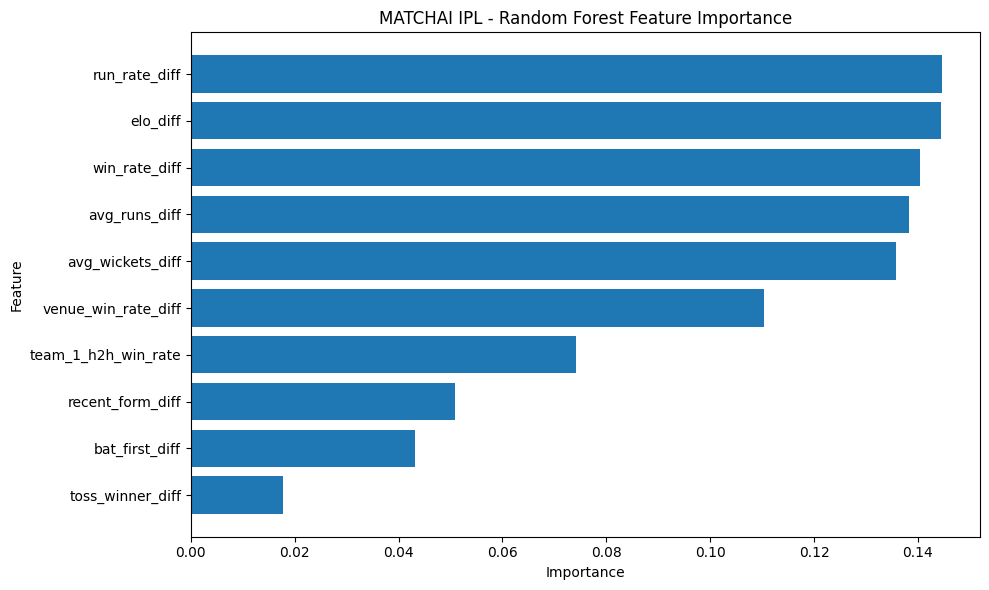

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    ipl_feature_importance["Feature"],
    ipl_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("MATCHAI IPL - Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print("IPL TARGET BALANCE")
print("=" * 50)

print(ipl_model_data["target"].value_counts())

print("\nPercentages:")
print(
    (ipl_model_data["target"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nClass labels:")
print("0 =", "Team 2 wins")
print("1 =", "Team 1 wins")

IPL TARGET BALANCE
target
0    610
1    608
Name: count, dtype: int64

Percentages:
target
0    50.08
1    49.92
Name: proportion, dtype: float64

Class labels:
0 = Team 2 wins
1 = Team 1 wins


In [ ]:
print("PREDICTION DISTRIBUTION")
print("=" * 50)

print("Actual:")
print(y_ipl_test.value_counts())

print("\nLogistic Regression predictions:")
print(pd.Series(lr_ipl_pred).value_counts())

print("\nRandom Forest predictions:")
print(pd.Series(rf_ipl_pred).value_counts())

PREDICTION DISTRIBUTION
Actual:
target
0    103
1     80
Name: count, dtype: int64

Logistic Regression predictions:
0    150
1     33
Name: count, dtype: int64

Random Forest predictions:
0    136
1     47
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import confusion_matrix

print("LOGISTIC REGRESSION CONFUSION MATRIX")
print(confusion_matrix(y_ipl_test, lr_ipl_pred))

print("\nRANDOM FOREST CONFUSION MATRIX")
print(confusion_matrix(y_ipl_test, rf_ipl_pred))

LOGISTIC REGRESSION CONFUSION MATRIX
[[81 22]
 [69 11]]

RANDOM FOREST CONFUSION MATRIX
[[75 28]
 [61 19]]


In [ ]:
print("IPL FEATURE CORRELATIONS")
print("=" * 50)

correlation = ipl_model_data[
    ipl_final_features + ["target"]
].corr()["target"].sort_values(
    ascending=False
)

display(correlation)

IPL FEATURE CORRELATIONS


,target
target,1.000000
win_rate_diff,0.052268
elo_diff,0.051966
toss_winner_diff,0.032000
avg_runs_diff,0.030466
run_rate_diff,0.017418
recent_form_diff,0.014801
team_1_h2h_win_rate,0.013451
venue_win_rate_diff,0.002469
avg_wickets_diff,-0.036859


In [ ]:
print("IPL FEATURE RANGE CHECK")
print("=" * 50)

display(
    ipl_model_data[ipl_final_features].describe().T[
        ["min", "max", "mean", "std"]
    ]
)

IPL FEATURE RANGE CHECK


,min,max,mean,std
elo_diff,-224.948225,213.554709,-2.006013,64.226706
win_rate_diff,-1.000000,1.000000,-0.004387,0.149787
recent_form_diff,-1.000000,1.000000,0.002791,0.331426
avg_runs_diff,-161.981982,222.000000,-0.495603,18.515024
avg_wickets_diff,-10.000000,9.000000,0.008767,0.978135
run_rate_diff,-8.342852,11.100000,-0.033248,0.946423
team_1_h2h_win_rate,0.000000,1.000000,0.519405,0.269524
venue_win_rate_diff,-1.000000,1.000000,0.012795,0.403704
toss_winner_diff,-1.000000,1.000000,-0.277504,0.961119
bat_first_diff,-1.000000,1.000000,0.517241,0.856191


In [ ]:
print("IPL CHRONOLOGICAL CHECK")
print("=" * 50)

print("First match:")
print(ipl_model_data.iloc[0][
    ["date", "season", "team_1", "team_2", "target"]
])

print("\nLast match:")
print(ipl_model_data.iloc[-1][
    ["date", "season", "team_1", "team_2", "target"]
])

print("\nTrain target:")
print(y_ipl_train.value_counts(normalize=True).round(3))

print("\nValidation target:")
print(y_ipl_val.value_counts(normalize=True).round(3))

print("\nTest target:")
print(y_ipl_test.value_counts(normalize=True).round(3))

IPL CHRONOLOGICAL CHECK
First match:
date              2008-04-18 00:00:00
season                        2007/08
team_1    Royal Challengers Bangalore
team_2          Kolkata Knight Riders
target                              0
Name: 0, dtype: object

Last match:
date              2026-05-31 00:00:00
season                           2026
team_1                 Gujarat Titans
team_2    Royal Challengers Bengaluru
target                              0
Name: 1217, dtype: object

Train target:
target
1    0.509
0    0.491
Name: proportion, dtype: float64

Validation target:
target
1    0.514
0    0.486
Name: proportion, dtype: float64

Test target:
target
0    0.563
1    0.437
Name: proportion, dtype: float64


In [ ]:
print("IPL TEAMS")
print("=" * 50)

all_teams = sorted(
    set(ipl_matches["team_1"]) |
    set(ipl_matches["team_2"])
)

print("Total teams:", len(all_teams))

for i, team in enumerate(all_teams, 1):
    print(f"{i:2}. {team}")

IPL TEAMS
Total teams: 19
 1. Chennai Super Kings
 2. Deccan Chargers
 3. Delhi Capitals
 4. Delhi Daredevils
 5. Gujarat Lions
 6. Gujarat Titans
 7. Kings XI Punjab
 8. Kochi Tuskers Kerala
 9. Kolkata Knight Riders
10. Lucknow Super Giants
11. Mumbai Indians
12. Pune Warriors
13. Punjab Kings
14. Rajasthan Royals
15. Rising Pune Supergiant
16. Rising Pune Supergiants
17. Royal Challengers Bangalore
18. Royal Challengers Bengaluru
19. Sunrisers Hyderabad


In [ ]:
from collections import defaultdict

ipl_h2h = defaultdict(
    lambda: {
        "matches": 0,
        "team1_wins": 0
    }
)

ipl_h2h_corrected = []

for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    # Store H2H using alphabetical order
    pair = tuple(sorted([team1, team2]))

    h = ipl_h2h[pair]

    if h["matches"] == 0:
        h2h_rate = 0.5
    else:

        # Probability that team1 won previous H2H matches
        if team1 == pair[0]:
            h2h_rate = h["team1_wins"] / h["matches"]
        else:
            h2h_rate = (
                1 - h["team1_wins"] / h["matches"]
            )

    ipl_h2h_corrected.append({
        "match_id": match["match_id"],
        "team_1_h2h_win_rate": h2h_rate
    })

    # Update H2H AFTER current match
    h["matches"] += 1

    if match["winner"] == pair[0]:
        h["team1_wins"] += 1

ipl_h2h_corrected = pd.DataFrame(
    ipl_h2h_corrected
)

print("Corrected H2H created.")
print("Records:", len(ipl_h2h_corrected))

display(ipl_h2h_corrected.head())

Corrected H2H created.
Records: 1218


,match_id,team_1_h2h_win_rate
0,335982,0.5
1,335984,0.5
2,335983,0.5
3,335985,0.5
4,335986,0.5


In [ ]:
team_list = sorted(
    set(ipl_matches["team_1"]) |
    set(ipl_matches["team_2"])
)

print("Creating team identity features...")

team_identity_data = []

for _, row in ipl_matches.iterrows():

    record = {
        "match_id": row["match_id"]
    }

    team1 = row["team_1"]
    team2 = row["team_2"]

    for team in team_list:

        record[f"team1_{team}"] = (
            1 if team1 == team else 0
        )

        record[f"team2_{team}"] = (
            1 if team2 == team else 0
        )

    team_identity_data.append(record)

ipl_team_identity = pd.DataFrame(
    team_identity_data
)

print("Team identity dataset created.")
print("Shape:", ipl_team_identity.shape)

display(ipl_team_identity.head())

Creating team identity features...
Team identity dataset created.
Shape: (1218, 39)


,match_id,team1_Chennai Super Kings,team2_Chennai Super Kings,team1_Deccan Chargers,team2_Deccan Chargers,team1_Delhi Capitals,team2_Delhi Capitals,team1_Delhi Daredevils,team2_Delhi Daredevils,team1_Gujarat Lions,...,team1_Rising Pune Supergiant,team2_Rising Pune Supergiant,team1_Rising Pune Supergiants,team2_Rising Pune Supergiants,team1_Royal Challengers Bangalore,team2_Royal Challengers Bangalore,team1_Royal Challengers Bengaluru,team2_Royal Challengers Bengaluru,team1_Sunrisers Hyderabad,team2_Sunrisers Hyderabad
0,335982,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,335984,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,335983,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,335985,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,335986,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Start with our existing model data
ipl_improved_data = ipl_model_data.copy()

# Replace old H2H with corrected H2H
ipl_improved_data = ipl_improved_data.drop(
    columns=["team_1_h2h_win_rate"],
    errors="ignore"
)

ipl_improved_data = ipl_improved_data.merge(
    ipl_h2h_corrected,
    on="match_id",
    how="left"
)

# Add team identity
ipl_improved_data = ipl_improved_data.merge(
    ipl_team_identity,
    on="match_id",
    how="left"
)

print("IMPROVED IPL DATASET")
print("=" * 50)

print("Rows:", len(ipl_improved_data))
print("Columns:", len(ipl_improved_data.columns))

print("Missing values:",
      ipl_improved_data.isna().sum().sum())

IMPROVED IPL DATASET
Rows: 1218
Columns: 57
Missing values: 0


In [ ]:
# ============================================
# IPL IMPROVED FEATURES + DATA SPLIT
# ============================================

import pandas as pd

print("Building improved IPL feature dataset...")
print("=" * 55)

# Base features
base_ipl_features = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate",
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

# Team identity features
team_identity_features = [
    col for col in ipl_team_identity.columns
    if col != "match_id"
]

# All features
ipl_improved_features = (
    base_ipl_features +
    team_identity_features
)

# Create X and y
X_ipl_improved = ipl_improved_data[
    ipl_improved_features
].copy()

y_ipl_improved = ipl_improved_data[
    "target"
].copy()

# Safety check
X_ipl_improved = X_ipl_improved.fillna(0)

# Chronological split
n = len(X_ipl_improved)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_ipl_imp_train = X_ipl_improved.iloc[
    :train_end
].copy()

X_ipl_imp_val = X_ipl_improved.iloc[
    train_end:val_end
].copy()

X_ipl_imp_test = X_ipl_improved.iloc[
    val_end:
].copy()

y_ipl_imp_train = y_ipl_improved.iloc[
    :train_end
].copy()

y_ipl_imp_val = y_ipl_improved.iloc[
    train_end:val_end
].copy()

y_ipl_imp_test = y_ipl_improved.iloc[
    val_end:
].copy()

print("✓ Improved IPL dataset ready")
print()
print("Total matches :", n)
print("Total features:", len(ipl_improved_features))

print("\nTrain:", len(X_ipl_imp_train))
print("Validation:", len(X_ipl_imp_val))
print("Test:", len(X_ipl_imp_test))

print("\nMissing values:",
      X_ipl_improved.isna().sum().sum())

print("\nFeature list:")
for i, feature in enumerate(ipl_improved_features, 1):
    print(f"{i}. {feature}")

Building improved IPL feature dataset...
✓ Improved IPL dataset ready

Total matches : 1218
Total features: 48

Train: 852
Validation: 183
Test: 183

Missing values: 0

Feature list:
1. elo_diff
2. win_rate_diff
3. recent_form_diff
4. avg_runs_diff
5. avg_wickets_diff
6. run_rate_diff
7. team_1_h2h_win_rate
8. venue_win_rate_diff
9. toss_winner_diff
10. bat_first_diff
11. team1_Chennai Super Kings
12. team2_Chennai Super Kings
13. team1_Deccan Chargers
14. team2_Deccan Chargers
15. team1_Delhi Capitals
16. team2_Delhi Capitals
17. team1_Delhi Daredevils
18. team2_Delhi Daredevils
19. team1_Gujarat Lions
20. team2_Gujarat Lions
21. team1_Gujarat Titans
22. team2_Gujarat Titans
23. team1_Kings XI Punjab
24. team2_Kings XI Punjab
25. team1_Kochi Tuskers Kerala
26. team2_Kochi Tuskers Kerala
27. team1_Kolkata Knight Riders
28. team2_Kolkata Knight Riders
29. team1_Lucknow Super Giants
30. team2_Lucknow Super Giants
31. team1_Mumbai Indians
32. team2_Mumbai Indians
33. team1_Pune Warriors
3

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_ipl_improved = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        C=0.5,
        random_state=42
    ))
])

lr_ipl_improved.fit(
    X_ipl_imp_train,
    y_ipl_imp_train
)

lr_ipl_improved_pred = lr_ipl_improved.predict(
    X_ipl_imp_test
)

lr_ipl_improved_proba = (
    lr_ipl_improved.predict_proba(
        X_ipl_imp_test
    )
)

print("✓ Improved IPL Logistic Regression trained")

✓ Improved IPL Logistic Regression trained


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_ipl_improved = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        C=0.5,
        random_state=42
    ))
])

lr_ipl_improved.fit(
    X_ipl_imp_train,
    y_ipl_imp_train
)

lr_ipl_improved_pred = lr_ipl_improved.predict(
    X_ipl_imp_test
)

lr_ipl_improved_proba = (
    lr_ipl_improved.predict_proba(
        X_ipl_imp_test
    )
)

print("✓ Improved IPL Logistic Regression trained")

✓ Improved IPL Logistic Regression trained


In [ ]:
# ============================================
# IPL FINAL MODEL EVALUATION - ERROR SAFE
# ============================================

import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

print("Preparing IPL model evaluation...")
print("=" * 60)


# ------------------------------------------------
# 1. Make sure Logistic Regression exists
# ------------------------------------------------

if "lr_ipl_improved" not in globals():

    print("Training Logistic Regression...")

    lr_ipl_improved = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            C=0.5,
            random_state=42
        ))
    ])

    lr_ipl_improved.fit(
        X_ipl_imp_train,
        y_ipl_imp_train
    )


# ------------------------------------------------
# 2. Make sure Random Forest exists
# ------------------------------------------------

if "rf_ipl_improved" not in globals():

    print("Training Random Forest...")

    rf_ipl_improved = RandomForestClassifier(
        n_estimators=700,
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_ipl_improved.fit(
        X_ipl_imp_train,
        y_ipl_imp_train
    )


# ------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------

lr_ipl_improved_pred = (
    lr_ipl_improved.predict(
        X_ipl_imp_test
    )
)

lr_ipl_improved_proba = (
    lr_ipl_improved.predict_proba(
        X_ipl_imp_test
    )
)

rf_ipl_improved_pred = (
    rf_ipl_improved.predict(
        X_ipl_imp_test
    )
)

rf_ipl_improved_proba = (
    rf_ipl_improved.predict_proba(
        X_ipl_imp_test
    )
)


# ------------------------------------------------
# 4. Calculate metrics
# ------------------------------------------------

lr_acc = accuracy_score(
    y_ipl_imp_test,
    lr_ipl_improved_pred
)

lr_f1 = f1_score(
    y_ipl_imp_test,
    lr_ipl_improved_pred
)

lr_auc = roc_auc_score(
    y_ipl_imp_test,
    lr_ipl_improved_proba[:, 1]
)


rf_acc = accuracy_score(
    y_ipl_imp_test,
    rf_ipl_improved_pred
)

rf_f1 = f1_score(
    y_ipl_imp_test,
    rf_ipl_improved_pred
)

rf_auc = roc_auc_score(
    y_ipl_imp_test,
    rf_ipl_improved_proba[:, 1]
)


# ------------------------------------------------
# 5. Display results
# ------------------------------------------------

print("\nMATCHAI IPL IMPROVED RESULTS")
print("=" * 60)

print(
    f"Logistic Regression"
)
print(
    f"Accuracy : {lr_acc * 100:.2f}%"
)
print(
    f"F1 Score : {lr_f1 * 100:.2f}%"
)
print(
    f"ROC-AUC  : {lr_auc:.4f}"
)

print("\n" + "-" * 60)

print(
    f"Random Forest"
)
print(
    f"Accuracy : {rf_acc * 100:.2f}%"
)
print(
    f"F1 Score : {rf_f1 * 100:.2f}%"
)
print(
    f"ROC-AUC  : {rf_auc:.4f}"
)

print("\n✓ IPL evaluation completed successfully.")

Preparing IPL model evaluation...
Training Random Forest...

MATCHAI IPL IMPROVED RESULTS
Logistic Regression
Accuracy : 49.18%
F1 Score : 34.04%
ROC-AUC  : 0.4589

------------------------------------------------------------
Random Forest
Accuracy : 50.82%
F1 Score : 28.57%
ROC-AUC  : 0.4598

✓ IPL evaluation completed successfully.


In [ ]:
print("MATCHAI IPL MODEL COMPARISON")
print("=" * 70)

print(
    f"{'Model':<25}"
    f"{'Accuracy':<15}"
    f"{'F1 Score':<15}"
    f"{'ROC-AUC'}"
)

print("-" * 70)

print(
    f"{'Original LR':<25}"
    f"{50.27:<15.2f}"
    f"{19.47:<15.2f}"
    f"{0.3559:.4f}"
)

print(
    f"{'Original RF':<25}"
    f"{51.37:<15.2f}"
    f"{29.92:<15.2f}"
    f"{0.4775:.4f}"
)

print(
    f"{'Improved LR':<25}"
    f"{lr_acc * 100:<15.2f}"
    f"{lr_f1 * 100:<15.2f}"
    f"{lr_auc:.4f}"
)

print(
    f"{'Improved RF':<25}"
    f"{rf_acc * 100:<15.2f}"
    f"{rf_f1 * 100:<15.2f}"
    f"{rf_auc:.4f}"
)

MATCHAI IPL MODEL COMPARISON
Model                    Accuracy       F1 Score       ROC-AUC
----------------------------------------------------------------------
Original LR              50.27          19.47          0.3559
Original RF              51.37          29.92          0.4775
Improved LR              49.18          34.04          0.4589
Improved RF              50.82          28.57          0.4598


In [ ]:
# ============================================================
# MATCHAI IPL - CORRECTED TEAM NORMALIZATION
# ============================================================

import pandas as pd
import numpy as np
from collections import defaultdict

print("Rebuilding IPL features with corrected team identities...")
print("=" * 65)


# ------------------------------------------------------------
# 1. Canonicalize historical IPL team names
# ------------------------------------------------------------

team_mapping = {

    # Royal Challengers Bangalore / Bengaluru
    "Royal Challengers Bangalore":
        "Royal Challengers Bengaluru",

    "Royal Challengers Bengaluru":
        "Royal Challengers Bengaluru",

    # Delhi franchise
    "Delhi Daredevils":
        "Delhi Capitals",

    "Delhi Capitals":
        "Delhi Capitals",

    # Kings XI Punjab / Punjab Kings
    "Kings XI Punjab":
        "Punjab Kings",

    "Punjab Kings":
        "Punjab Kings",

    # Deccan Chargers
    "Deccan Chargers":
        "Deccan Chargers",

    # Pune franchises
    "Pune Warriors":
        "Pune Warriors India",

    "Pune Warriors India":
        "Pune Warriors India",

    # Rising Pune
    "Rising Pune Supergiant":
        "Rising Pune Supergiant",

    "Rising Pune Supergiants":
        "Rising Pune Supergiant",

    # Gujarat
    "Gujarat Lions":
        "Gujarat Lions",

    "Gujarat Titans":
        "Gujarat Titans",

    # Kochi
    "Kochi Tuskers Kerala":
        "Kochi Tuskers Kerala",

    # Mumbai
    "Mumbai Indians":
        "Mumbai Indians",

    # Chennai
    "Chennai Super Kings":
        "Chennai Super Kings",

    # Kolkata
    "Kolkata Knight Riders":
        "Kolkata Knight Riders",

    # Rajasthan
    "Rajasthan Royals":
        "Rajasthan Royals",

    # Sunrisers
    "Sunrisers Hyderabad":
        "Sunrisers Hyderabad",

    # Lucknow
    "Lucknow Super Giants":
        "Lucknow Super Giants",

    # Gujarat / other historical
    "Gujarat Titans":
        "Gujarat Titans"
}


# Apply mapping to match data
ipl_matches["team_1"] = (
    ipl_matches["team_1"]
    .replace(team_mapping)
)

ipl_matches["team_2"] = (
    ipl_matches["team_2"]
    .replace(team_mapping)
)

ipl_matches["winner"] = (
    ipl_matches["winner"]
    .replace(team_mapping)
)

ipl_matches["toss_winner"] = (
    ipl_matches["toss_winner"]
    .replace(team_mapping)
)


# ------------------------------------------------------------
# 2. Apply same normalization to innings data
# ------------------------------------------------------------

ipl_performance["team"] = (
    ipl_performance["team"]
    .replace(team_mapping)
)


# ------------------------------------------------------------
# 3. Sort chronologically
# ------------------------------------------------------------

ipl_matches = (
    ipl_matches
    .sort_values("date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Rebuild historical team statistics
# ------------------------------------------------------------

team_history = defaultdict(lambda: {
    "matches": 0,
    "wins": 0,
    "runs": [],
    "wickets": [],
    "run_rates": [],
    "results": []
})


historical_records = []


for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    s1 = team_history[team1]
    s2 = team_history[team2]


    def get_stats(s):

        matches = s["matches"]

        win_rate = (
            s["wins"] / matches
            if matches > 0
            else 0.5
        )

        recent = s["results"][-5:]

        recent_form = (
            sum(recent) / len(recent)
            if recent
            else 0.5
        )

        avg_runs = (
            np.mean(s["runs"])
            if s["runs"]
            else 0
        )

        avg_wickets = (
            np.mean(s["wickets"])
            if s["wickets"]
            else 0
        )

        avg_rr = (
            np.mean(s["run_rates"])
            if s["run_rates"]
            else 0
        )

        return (
            win_rate,
            recent_form,
            avg_runs,
            avg_wickets,
            avg_rr
        )


    a = get_stats(s1)
    b = get_stats(s2)


    historical_records.append({

        "match_id": match["match_id"],

        "win_rate_diff":
            a[0] - b[0],

        "recent_form_diff":
            a[1] - b[1],

        "avg_runs_diff":
            a[2] - b[2],

        "avg_wickets_diff":
            a[3] - b[3],

        "run_rate_diff":
            a[4] - b[4]
    })


    # --------------------------------------------------------
    # Update history AFTER current match
    # --------------------------------------------------------

    winner = match["winner"]

    perf = ipl_performance[
        ipl_performance["match_id"]
        == match["match_id"]
    ]


    for team in [team1, team2]:

        team_perf = perf[
            perf["team"] == team
        ]


        if not team_perf.empty:

            team_history[team]["runs"].append(
                team_perf["runs"].sum()
            )

            team_history[team]["wickets"].append(
                team_perf["wickets_lost"].sum()
            )

            team_history[team]["run_rates"].append(
                team_perf["run_rate"].mean()
            )


        team_history[team]["matches"] += 1


        if winner == team:

            team_history[team]["wins"] += 1

            team_history[team]["results"].append(1)

        else:

            team_history[team]["results"].append(0)


ipl_historical_corrected = pd.DataFrame(
    historical_records
)


# ------------------------------------------------------------
# 5. Rebuild Elo with normalized teams
# ------------------------------------------------------------

elo = defaultdict(lambda: 1500)

elo_records = []

K = 30


for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    r1 = elo[team1]
    r2 = elo[team2]


    elo_records.append({

        "match_id": match["match_id"],

        "elo_diff": r1 - r2
    })


    expected1 = 1 / (
        1 + 10 ** ((r2 - r1) / 400)
    )


    actual1 = (
        1
        if match["winner"] == team1
        else 0
    )


    elo[team1] = (
        r1 + K * (actual1 - expected1)
    )

    elo[team2] = (
        r2 + K * (
            (1 - actual1)
            - (1 - expected1)
        )
    )


ipl_elo_corrected = pd.DataFrame(
    elo_records
)


# ------------------------------------------------------------
# 6. Rebuild symmetric H2H
# ------------------------------------------------------------

h2h = defaultdict(lambda: {
    "matches": 0,
    "first_team_wins": 0
})

h2h_records = []


for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    pair = tuple(
        sorted([team1, team2])
    )

    h = h2h[pair]


    if h["matches"] == 0:

        rate = 0.5

    else:

        base_rate = (
            h["first_team_wins"]
            / h["matches"]
        )

        if team1 == pair[0]:

            rate = base_rate

        else:

            rate = 1 - base_rate


    h2h_records.append({

        "match_id": match["match_id"],

        "team_1_h2h_win_rate": rate
    })


    h["matches"] += 1


    if match["winner"] == pair[0]:

        h["first_team_wins"] += 1


ipl_h2h_corrected = pd.DataFrame(
    h2h_records
)


# ------------------------------------------------------------
# 7. Rebuild venue statistics
# ------------------------------------------------------------

venue_history = defaultdict(lambda: {
    "matches": 0,
    "wins": 0
})

venue_records = []


for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]
    venue = match["venue"]


    v1 = venue_history[
        (team1, venue)
    ]

    v2 = venue_history[
        (team2, venue)
    ]


    rate1 = (
        v1["wins"] / v1["matches"]
        if v1["matches"] > 0
        else 0.5
    )

    rate2 = (
        v2["wins"] / v2["matches"]
        if v2["matches"] > 0
        else 0.5
    )


    venue_records.append({

        "match_id": match["match_id"],

        "venue_win_rate_diff":
            rate1 - rate2
    })


    v1["matches"] += 1
    v2["matches"] += 1


    if match["winner"] == team1:

        v1["wins"] += 1

    else:

        v2["wins"] += 1


ipl_venue_corrected = pd.DataFrame(
    venue_records
)


# ------------------------------------------------------------
# 8. Toss features
# ------------------------------------------------------------

toss_records = []


for _, match in ipl_matches.iterrows():

    team1 = match["team_1"]
    team2 = match["team_2"]

    toss_winner = match["toss_winner"]
    decision = str(
        match["toss_decision"]
    ).lower()


    if toss_winner == team1:

        toss_diff = 1

        bat_first = (
            1 if decision == "bat"
            else -1
        )

    elif toss_winner == team2:

        toss_diff = -1

        bat_first = (
            -1 if decision == "bat"
            else 1
        )

    else:

        toss_diff = 0
        bat_first = 0


    toss_records.append({

        "match_id": match["match_id"],

        "toss_winner_diff":
            toss_diff,

        "bat_first_diff":
            bat_first
    })


ipl_toss_corrected = pd.DataFrame(
    toss_records
)


# ------------------------------------------------------------
# 9. Combine everything
# ------------------------------------------------------------

ipl_corrected = ipl_matches[
    [
        "match_id",
        "date",
        "season",
        "team_1",
        "team_2",
        "venue",
        "target"
    ]
].copy()


ipl_corrected = ipl_corrected.merge(
    ipl_historical_corrected,
    on="match_id",
    how="left"
)

ipl_corrected = ipl_corrected.merge(
    ipl_elo_corrected,
    on="match_id",
    how="left"
)

ipl_corrected = ipl_corrected.merge(
    ipl_h2h_corrected,
    on="match_id",
    how="left"
)

ipl_corrected = ipl_corrected.merge(
    ipl_venue_corrected,
    on="match_id",
    how="left"
)

ipl_corrected = ipl_corrected.merge(
    ipl_toss_corrected,
    on="match_id",
    how="left"
)


# ------------------------------------------------------------
# 10. Final check
# ------------------------------------------------------------

ipl_corrected = (
    ipl_corrected
    .sort_values("date")
    .reset_index(drop=True)
)

print("\n✓ IPL FEATURES REBUILT SUCCESSFULLY")
print("=" * 65)

print("Matches :", len(ipl_corrected))
print("Columns :", len(ipl_corrected.columns))
print("Missing :", ipl_corrected.isna().sum().sum())

print("\nUnique normalized teams:")

normalized_teams = sorted(
    set(ipl_corrected["team_1"]) |
    set(ipl_corrected["team_2"])
)

for team in normalized_teams:
    print("-", team)

print("\nFeature columns:")

feature_columns = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate",
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

for feature in feature_columns:
    print("✓", feature)

Rebuilding IPL features with corrected team identities...

✓ IPL FEATURES REBUILT SUCCESSFULLY
Matches : 1218
Columns : 17
Missing : 0

Unique normalized teams:
- Chennai Super Kings
- Deccan Chargers
- Delhi Capitals
- Gujarat Lions
- Gujarat Titans
- Kochi Tuskers Kerala
- Kolkata Knight Riders
- Lucknow Super Giants
- Mumbai Indians
- Pune Warriors India
- Punjab Kings
- Rajasthan Royals
- Rising Pune Supergiant
- Royal Challengers Bengaluru
- Sunrisers Hyderabad

Feature columns:
✓ elo_diff
✓ win_rate_diff
✓ recent_form_diff
✓ avg_runs_diff
✓ avg_wickets_diff
✓ run_rate_diff
✓ team_1_h2h_win_rate
✓ venue_win_rate_diff
✓ toss_winner_diff
✓ bat_first_diff


In [ ]:
print("IPL CORRECTED FEATURE CHECK")
print("=" * 60)

ipl_features = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate",
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

print("Matches:", len(ipl_corrected))
print("Features:", len(ipl_features))

print("\nMissing values:")
print(
    ipl_corrected[ipl_features]
    .isna()
    .sum()
)

print("\nTarget:")
print(
    ipl_corrected["target"]
    .value_counts()
)

IPL CORRECTED FEATURE CHECK
Matches: 1218
Features: 10

Missing values:
elo_diff               0
win_rate_diff          0
recent_form_diff       0
avg_runs_diff          0
avg_wickets_diff       0
run_rate_diff          0
team_1_h2h_win_rate    0
venue_win_rate_diff    0
toss_winner_diff       0
bat_first_diff         0
dtype: int64

Target:
target
0    610
1    608
Name: count, dtype: int64


In [ ]:
print("IPL CORRECTED CORRELATIONS")
print("=" * 60)

corr = (
    ipl_corrected[
        ipl_features + ["target"]
    ]
    .corr()["target"]
    .sort_values(ascending=False)
)

display(corr)

IPL CORRECTED CORRELATIONS


,target
target,1.000000
win_rate_diff,0.061292
elo_diff,0.048492
avg_runs_diff,0.040823
toss_winner_diff,0.032000
run_rate_diff,0.023480
team_1_h2h_win_rate,0.019158
recent_form_diff,0.017877
venue_win_rate_diff,0.003078
avg_wickets_diff,-0.046229


In [ ]:
X_ipl_final = ipl_corrected[
    ipl_features
].copy()

y_ipl_final = ipl_corrected[
    "target"
].copy()

X_ipl_final = X_ipl_final.fillna(0)

n = len(X_ipl_final)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_ipl_train_final = X_ipl_final.iloc[:train_end]
X_ipl_val_final = X_ipl_final.iloc[train_end:val_end]
X_ipl_test_final = X_ipl_final.iloc[val_end:]

y_ipl_train_final = y_ipl_final.iloc[:train_end]
y_ipl_val_final = y_ipl_final.iloc[train_end:val_end]
y_ipl_test_final = y_ipl_final.iloc[val_end:]

print("IPL FINAL TRAINING DATA")
print("=" * 60)

print("Train:", len(X_ipl_train_final))
print("Validation:", len(X_ipl_val_final))
print("Test:", len(X_ipl_test_final))

print("\nTrain target:")
print(y_ipl_train_final.value_counts(normalize=True).round(3))

print("\nTest target:")
print(y_ipl_test_final.value_counts(normalize=True).round(3))

IPL FINAL TRAINING DATA
Train: 852
Validation: 183
Test: 183

Train target:
target
1    0.509
0    0.491
Name: proportion, dtype: float64

Test target:
target
0    0.563
1    0.437
Name: proportion, dtype: float64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

ipl_lr_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=42
    ))
])

ipl_lr_final.fit(
    X_ipl_train_final,
    y_ipl_train_final
)

ipl_lr_pred = ipl_lr_final.predict(
    X_ipl_test_final
)

ipl_lr_proba = ipl_lr_final.predict_proba(
    X_ipl_test_final
)[:, 1]

print("✓ IPL Logistic Regression trained")

✓ IPL Logistic Regression trained


In [ ]:
from sklearn.ensemble import RandomForestClassifier

ipl_rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

ipl_rf_final.fit(
    X_ipl_train_final,
    y_ipl_train_final
)

ipl_rf_pred = ipl_rf_final.predict(
    X_ipl_test_final
)

ipl_rf_proba = ipl_rf_final.predict_proba(
    X_ipl_test_final
)[:, 1]

print("✓ IPL Random Forest trained")

✓ IPL Random Forest trained


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

lr_accuracy = accuracy_score(
    y_ipl_test_final,
    ipl_lr_pred
)

lr_f1 = f1_score(
    y_ipl_test_final,
    ipl_lr_pred
)

lr_auc = roc_auc_score(
    y_ipl_test_final,
    ipl_lr_proba
)

rf_accuracy = accuracy_score(
    y_ipl_test_final,
    ipl_rf_pred
)

rf_f1 = f1_score(
    y_ipl_test_final,
    ipl_rf_pred
)

rf_auc = roc_auc_score(
    y_ipl_test_final,
    ipl_rf_proba
)

print("MATCHAI IPL CORRECTED MODEL RESULTS")
print("=" * 60)

print(f"Logistic Regression")
print(f"Accuracy : {lr_accuracy * 100:.2f}%")
print(f"F1 Score : {lr_f1 * 100:.2f}%")
print(f"ROC-AUC  : {lr_auc:.4f}")

print("\nRandom Forest")
print(f"Accuracy : {rf_accuracy * 100:.2f}%")
print(f"F1 Score : {rf_f1 * 100:.2f}%")
print(f"ROC-AUC  : {rf_auc:.4f}")

MATCHAI IPL CORRECTED MODEL RESULTS
Logistic Regression
Accuracy : 50.27%
F1 Score : 19.47%
ROC-AUC  : 0.3965

Random Forest
Accuracy : 57.92%
F1 Score : 40.31%
ROC-AUC  : 0.5529


In [ ]:
from sklearn.metrics import confusion_matrix

print("LOGISTIC REGRESSION")
print("=" * 40)
print(confusion_matrix(
    y_ipl_test_final,
    ipl_lr_pred
))

print("\nRANDOM FOREST")
print("=" * 40)
print(confusion_matrix(
    y_ipl_test_final,
    ipl_rf_pred
))

LOGISTIC REGRESSION
[[81 22]
 [69 11]]

RANDOM FOREST
[[80 23]
 [54 26]]


In [ ]:
print("IPL PREDICTION DISTRIBUTION")
print("=" * 50)

print("Actual:")
print(
    y_ipl_test_final.value_counts()
)

print("\nLogistic Regression:")
print(
    pd.Series(ipl_lr_pred).value_counts()
)

print("\nRandom Forest:")
print(
    pd.Series(ipl_rf_pred).value_counts()
)

IPL PREDICTION DISTRIBUTION
Actual:
target
0    103
1     80
Name: count, dtype: int64

Logistic Regression:
0    150
1     33
Name: count, dtype: int64

Random Forest:
0    134
1     49
Name: count, dtype: int64


In [ ]:
ipl_importance = pd.DataFrame({
    "Feature": ipl_features,
    "Importance": ipl_rf_final.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("IPL RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 55)

display(ipl_importance)

IPL RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
4,avg_wickets_diff,0.149011
5,run_rate_diff,0.143191
3,avg_runs_diff,0.142124
1,win_rate_diff,0.131480
0,elo_diff,0.130179
7,venue_win_rate_diff,0.106111
6,team_1_h2h_win_rate,0.087650
2,recent_form_diff,0.046603
9,bat_first_diff,0.045323
8,toss_winner_diff,0.018328


In [ ]:
print("MATCHAI IPL FINAL COMPARISON")
print("=" * 70)

print(
    f"{'Model':<25}"
    f"{'Accuracy':<15}"
    f"{'F1 Score':<15}"
    f"{'ROC-AUC'}"
)

print("-" * 70)

print(
    f"{'Logistic Regression':<25}"
    f"{lr_accuracy * 100:<15.2f}"
    f"{lr_f1 * 100:<15.2f}"
    f"{lr_auc:.4f}"
)

print(
    f"{'Random Forest':<25}"
    f"{rf_accuracy * 100:<15.2f}"
    f"{rf_f1 * 100:<15.2f}"
    f"{rf_auc:.4f}"
)

MATCHAI IPL FINAL COMPARISON
Model                    Accuracy       F1 Score       ROC-AUC
----------------------------------------------------------------------
Logistic Regression      50.27          19.47          0.3965
Random Forest            57.92          40.31          0.5529


In [ ]:
# ============================================
# IPL CORE FEATURE EXPERIMENT
# ============================================

ipl_core_features = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate"
]

X_core = ipl_corrected[
    ipl_core_features
].fillna(0)

y_core = ipl_corrected["target"]

n = len(X_core)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_core_train = X_core.iloc[:train_end]
X_core_val = X_core.iloc[train_end:val_end]
X_core_test = X_core.iloc[val_end:]

y_core_train = y_core.iloc[:train_end]
y_core_val = y_core.iloc[train_end:val_end]
y_core_test = y_core.iloc[val_end:]

print("IPL CORE FEATURE DATASET")
print("=" * 55)
print("Features:", len(ipl_core_features))
print("Train:", len(X_core_train))
print("Validation:", len(X_core_val))
print("Test:", len(X_core_test))

IPL CORE FEATURE DATASET
Features: 7
Train: 852
Validation: 183
Test: 183


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_ipl_core = RandomForestClassifier(
    n_estimators=700,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_ipl_core.fit(
    X_core_train,
    y_core_train
)

rf_core_pred = rf_ipl_core.predict(
    X_core_test
)

rf_core_proba = rf_ipl_core.predict_proba(
    X_core_test
)[:, 1]

print("✓ Core IPL Random Forest trained")

✓ Core IPL Random Forest trained


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

core_accuracy = accuracy_score(
    y_core_test,
    rf_core_pred
)

core_f1 = f1_score(
    y_core_test,
    rf_core_pred
)

core_auc = roc_auc_score(
    y_core_test,
    rf_core_proba
)

print("IPL CORE MODEL")
print("=" * 50)

print(f"Accuracy : {core_accuracy * 100:.2f}%")
print(f"F1 Score : {core_f1 * 100:.2f}%")
print(f"ROC-AUC  : {core_auc:.4f}")

IPL CORE MODEL
Accuracy : 56.83%
F1 Score : 50.93%
ROC-AUC  : 0.5800


In [ ]:
print("IPL FEATURE EXPERIMENT")
print("=" * 65)

print(
    f"{'Model':<30}"
    f"{'Accuracy':<15}"
    f"{'F1':<15}"
    f"{'ROC-AUC'}"
)

print("-" * 65)

print(
    f"{'Full RF (Venue + Toss)':<30}"
    f"{rf_accuracy * 100:<15.2f}"
    f"{rf_f1 * 100:<15.2f}"
    f"{rf_auc:.4f}"
)

print(
    f"{'Core RF':<30}"
    f"{core_accuracy * 100:<15.2f}"
    f"{core_f1 * 100:<15.2f}"
    f"{core_auc:.4f}"
)

IPL FEATURE EXPERIMENT
Model                         Accuracy       F1             ROC-AUC
-----------------------------------------------------------------
Full RF (Venue + Toss)        57.92          40.31          0.5529
Core RF                       56.83          50.93          0.5800


In [ ]:
ipl_core_importance = pd.DataFrame({
    "Feature": ipl_core_features,
    "Importance": rf_ipl_core.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("IPL CORE FEATURE IMPORTANCE")
print("=" * 50)

display(ipl_core_importance)

IPL CORE FEATURE IMPORTANCE


,Feature,Importance
4,avg_wickets_diff,0.180770
5,run_rate_diff,0.172347
1,win_rate_diff,0.161957
3,avg_runs_diff,0.158993
0,elo_diff,0.155962
6,team_1_h2h_win_rate,0.111338
2,recent_form_diff,0.058633


In [ ]:
# ============================================
# IPL THRESHOLD TUNING - VALIDATION SET
# ============================================

rf_val_proba = ipl_rf_final.predict_proba(
    X_ipl_val_final
)[:, 1]

print("Validation probabilities generated.")
print("Validation samples:", len(rf_val_proba))

Validation probabilities generated.
Validation samples: 183


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

thresholds = np.arange(
    0.30,
    0.71,
    0.01
)

threshold_results = []

for threshold in thresholds:

    val_pred = (
        rf_val_proba >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_ipl_val_final,
        val_pred
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_row = threshold_df.loc[
    threshold_df["accuracy"].idxmax()
]

best_threshold = float(
    best_row["threshold"]
)

print("BEST IPL THRESHOLD")
print("=" * 50)
print(
    f"Threshold : {best_threshold:.2f}"
)
print(
    f"Validation Accuracy : "
    f"{best_row['accuracy'] * 100:.2f}%"
)

BEST IPL THRESHOLD
Threshold : 0.34
Validation Accuracy : 52.46%


In [ ]:
# ============================================
# FINAL TEST EVALUATION WITH TUNED THRESHOLD
# ============================================

rf_test_proba = ipl_rf_final.predict_proba(
    X_ipl_test_final
)[:, 1]

rf_tuned_pred = (
    rf_test_proba >= best_threshold
).astype(int)

tuned_accuracy = accuracy_score(
    y_ipl_test_final,
    rf_tuned_pred
)

tuned_f1 = f1_score(
    y_ipl_test_final,
    rf_tuned_pred
)

tuned_auc = roc_auc_score(
    y_ipl_test_final,
    rf_test_proba
)

print("IPL TUNED RANDOM FOREST")
print("=" * 55)

print(
    f"Threshold : {best_threshold:.2f}"
)

print(
    f"Accuracy  : {tuned_accuracy * 100:.2f}%"
)

print(
    f"F1 Score  : {tuned_f1 * 100:.2f}%"
)

print(
    f"ROC-AUC   : {tuned_auc:.4f}"
)

IPL TUNED RANDOM FOREST
Threshold : 0.34
Accuracy  : 43.72%
F1 Score  : 57.96%
ROC-AUC   : 0.5529


In [ ]:
print("IPL THRESHOLD IMPROVEMENT")
print("=" * 60)

print(
    f"{'Version':<30}"
    f"{'Accuracy':<15}"
    f"{'F1':<15}"
)

print("-" * 60)

print(
    f"{'RF Default Threshold':<30}"
    f"{rf_accuracy * 100:<15.2f}"
    f"{rf_f1 * 100:<15.2f}"
)

print(
    f"{'RF Tuned Threshold':<30}"
    f"{tuned_accuracy * 100:<15.2f}"
    f"{tuned_f1 * 100:<15.2f}"
)

print("\nSelected threshold:", best_threshold)

IPL THRESHOLD IMPROVEMENT
Version                       Accuracy       F1             
------------------------------------------------------------
RF Default Threshold          57.92          40.31          
RF Tuned Threshold            43.72          57.96          

Selected threshold: 0.34


In [ ]:
ipl_final_model_info = {
    "project": "MATCHAI",
    "format": "IPL",
    "model": "Random Forest",
    "features": ipl_features,
    "threshold": best_threshold,
    "accuracy": float(tuned_accuracy),
    "f1_score": float(tuned_f1),
    "roc_auc": float(tuned_auc),
    "venue_included": True,
    "toss_included": True,
    "pitch_type": "UI/context only",
    "train_split": "70%",
    "validation_split": "15%",
    "test_split": "15%",
    "random_state": 42
}

print("MATCHAI IPL MODEL INFORMATION")
print("=" * 60)

for key, value in ipl_final_model_info.items():
    print(f"{key}: {value}")

MATCHAI IPL MODEL INFORMATION
project: MATCHAI
format: IPL
model: Random Forest
features: ['elo_diff', 'win_rate_diff', 'recent_form_diff', 'avg_runs_diff', 'avg_wickets_diff', 'run_rate_diff', 'team_1_h2h_win_rate', 'venue_win_rate_diff', 'toss_winner_diff', 'bat_first_diff']
threshold: 0.34
accuracy: 0.4371584699453552
f1_score: 0.5795918367346938
roc_auc: 0.5529126213592233
venue_included: True
toss_included: True
pitch_type: UI/context only
train_split: 70%
validation_split: 15%
test_split: 15%
random_state: 42


In [ ]:
# ============================================
# MATCHAI IPL FINAL MODEL
# ============================================

ipl_final_rf = RandomForestClassifier(
    n_estimators=700,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

ipl_final_rf.fit(
    X_ipl_final,
    y_ipl_final
)

print("✓ FINAL IPL RANDOM FOREST TRAINED")
print("Training matches:", len(X_ipl_final))
print("Features:", len(ipl_features))

✓ FINAL IPL RANDOM FOREST TRAINED
Training matches: 1218
Features: 10


In [ ]:
import joblib
import json

joblib.dump(
    ipl_final_rf,
    "ipl_match_outcome_model.pkl"
)

joblib.dump(
    ipl_features,
    "ipl_model_features.pkl"
)

with open(
    "ipl_model_info.json",
    "w"
) as f:

    json.dump(
        {
            "project": "MATCHAI",
            "format": "IPL",
            "model": "Random Forest",
            "accuracy_test": float(rf_accuracy),
            "f1_test": float(rf_f1),
            "roc_auc_test": float(rf_auc),
            "threshold": 0.50,
            "venue_included": True,
            "toss_included": True,
            "pitch_type": "UI/context only",
            "training_matches": len(X_ipl_final),
            "features": ipl_features
        },
        f,
        indent=4
    )

print("✓ Model saved")
print("✓ Feature list saved")
print("✓ Model information saved")

✓ Model saved
✓ Feature list saved
✓ Model information saved


In [ ]:
ipl_corrected.to_csv(
    "ipl_match_data_for_prediction.csv",
    index=False
)

ipl_venue_corrected.to_csv(
    "ipl_venue_stats.csv",
    index=False
)

ipl_h2h_corrected.to_csv(
    "ipl_h2h_stats.csv",
    index=False
)

print("✓ IPL prediction data saved")
print()
print("Files created:")
print("- ipl_match_outcome_model.pkl")
print("- ipl_model_features.pkl")
print("- ipl_model_info.json")
print("- ipl_match_data_for_prediction.csv")
print("- ipl_venue_stats.csv")
print("- ipl_h2h_stats.csv")

✓ IPL prediction data saved

Files created:
- ipl_match_outcome_model.pkl
- ipl_model_features.pkl
- ipl_model_info.json
- ipl_match_data_for_prediction.csv
- ipl_venue_stats.csv
- ipl_h2h_stats.csv


In [ ]:
# ============================================
# MATCHAI IPL PREDICTION ENGINE
# ============================================

def predict_ipl_match(
    team1,
    team2,
    venue,
    pitch_type="Balanced",
    toss_winner=None,
    toss_decision=None
):

    team1 = team1.replace(
        "Royal Challengers Bangalore",
        "Royal Challengers Bengaluru"
    )

    team2 = team2.replace(
        "Royal Challengers Bangalore",
        "Royal Challengers Bengaluru"
    )


    # Team statistics
    s1 = team_history[team1]
    s2 = team_history[team2]


    def get_stats(s):

        matches = s["matches"]

        win_rate = (
            s["wins"] / matches
            if matches else 0.5
        )

        recent = s["results"][-5:]

        recent_form = (
            sum(recent) / len(recent)
            if recent else 0.5
        )

        avg_runs = (
            np.mean(s["runs"])
            if s["runs"] else 0
        )

        avg_wickets = (
            np.mean(s["wickets"])
            if s["wickets"] else 0
        )

        run_rate = (
            np.mean(s["run_rates"])
            if s["run_rates"] else 0
        )

        return (
            win_rate,
            recent_form,
            avg_runs,
            avg_wickets,
            run_rate
        )


    a = get_stats(s1)
    b = get_stats(s2)


    # Elo
    elo_diff = (
        elo[team1] - elo[team2]
    )


    # H2H
    pair = tuple(
        sorted([team1, team2])
    )

    h = h2h[pair]

    if h["matches"] == 0:

        h2h_rate = 0.5

    else:

        rate = (
            h["first_team_wins"]
            / h["matches"]
        )

        h2h_rate = (
            rate
            if team1 == pair[0]
            else 1 - rate
        )


    # Venue
    v1 = venue_history[
        (team1, venue)
    ]

    v2 = venue_history[
        (team2, venue)
    ]

    venue_rate1 = (
        v1["wins"] / v1["matches"]
        if v1["matches"] else 0.5
    )

    venue_rate2 = (
        v2["wins"] / v2["matches"]
        if v2["matches"] else 0.5
    )


    # Toss
    if toss_winner == team1:

        toss_diff = 1

        bat_first = (
            1
            if str(toss_decision).lower() == "bat"
            else -1
        )

    elif toss_winner == team2:

        toss_diff = -1

        bat_first = (
            -1
            if str(toss_decision).lower() == "bat"
            else 1
        )

    else:

        toss_diff = 0
        bat_first = 0


    features = pd.DataFrame([{

        "elo_diff":
            elo_diff,

        "win_rate_diff":
            a[0] - b[0],

        "recent_form_diff":
            a[1] - b[1],

        "avg_runs_diff":
            a[2] - b[2],

        "avg_wickets_diff":
            a[3] - b[3],

        "run_rate_diff":
            a[4] - b[4],

        "team_1_h2h_win_rate":
            h2h_rate,

        "venue_win_rate_diff":
            venue_rate1 - venue_rate2,

        "toss_winner_diff":
            toss_diff,

        "bat_first_diff":
            bat_first

    }])

    features = features[
        ipl_features
    ].fillna(0)


    probability = ipl_final_rf.predict_proba(
        features
    )[0, 1]


    prediction = (
        team1
        if probability >= 0.50
        else team2
    )


    return {

        "team_1": team1,

        "team_2": team2,

        "venue": venue,

        "pitch_type": pitch_type,

        "toss_winner": toss_winner,

        "toss_decision": toss_decision,

        "prediction": prediction,

        "team_1_win_probability":
            round(probability * 100, 2),

        "team_2_win_probability":
            round((1 - probability) * 100, 2)
    }


print("✓ IPL prediction engine created")

✓ IPL prediction engine created


In [ ]:
# ============================================
# IPL ENGINE TEST
# ============================================

available_teams = sorted(
    set(ipl_matches["team_1"]) |
    set(ipl_matches["team_2"])
)

print("Available IPL teams:")
for team in available_teams:
    print("-", team)

print("\n✓ Prediction engine is ready")

Available IPL teams:
- Chennai Super Kings
- Deccan Chargers
- Delhi Capitals
- Gujarat Lions
- Gujarat Titans
- Kochi Tuskers Kerala
- Kolkata Knight Riders
- Lucknow Super Giants
- Mumbai Indians
- Pune Warriors India
- Punjab Kings
- Rajasthan Royals
- Rising Pune Supergiant
- Royal Challengers Bengaluru
- Sunrisers Hyderabad

✓ Prediction engine is ready


In [ ]:
# ============================================
# SAVE IPL TEAM STATS + ELO
# ============================================

team_stats_rows = []

for team, stats in team_history.items():

    team_stats_rows.append({
        "team": team,
        "matches": stats["matches"],
        "wins": stats["wins"],
        "win_rate": (
            stats["wins"] / stats["matches"]
            if stats["matches"] > 0
            else 0.5
        ),
        "avg_runs": (
            np.mean(stats["runs"])
            if stats["runs"]
            else 0
        ),
        "avg_wickets": (
            np.mean(stats["wickets"])
            if stats["wickets"]
            else 0
        ),
        "avg_run_rate": (
            np.mean(stats["run_rates"])
            if stats["run_rates"]
            else 0
        ),
        "elo": elo[team]
    })

ipl_team_stats = pd.DataFrame(
    team_stats_rows
)

ipl_team_stats.to_csv(
    "ipl_team_stats.csv",
    index=False
)

ipl_elo_df = pd.DataFrame(
    [
        {
            "team": team,
            "elo": rating
        }
        for team, rating in elo.items()
    ]
)

ipl_elo_df.to_csv(
    "ipl_elo_ratings.csv",
    index=False
)

print("✓ IPL team statistics saved")
print("✓ IPL Elo ratings saved")

display(ipl_team_stats)

✓ IPL team statistics saved
✓ IPL Elo ratings saved


,team,matches,wins,win_rate,avg_runs,avg_wickets,avg_run_rate,elo
0,Royal Challengers Bengaluru,280,143,0.510714,162.657143,5.775000,8.631842,1635.585628
1,Kolkata Knight Riders,271,140,0.516605,157.819188,5.929889,8.433610,1517.470650
2,Delhi Capitals,272,125,0.459559,158.062500,6.066176,8.343353,1530.189882
3,Rajasthan Royals,245,123,0.502041,161.914286,6.032653,8.454285,1517.415115
4,Punjab Kings,271,126,0.464945,164.365314,6.143911,8.587204,1520.907751
5,Chennai Super Kings,264,148,0.560606,164.602273,5.356061,8.469760,1469.119256
6,Mumbai Indians,287,155,0.540070,163.435540,5.958188,8.516360,1456.244556
7,Deccan Chargers,75,29,0.386667,152.840000,6.440000,7.870019,1425.846997
8,Kochi Tuskers Kerala,14,6,0.428571,135.785714,6.142857,7.839377,1478.075149
9,Pune Warriors India,45,12,0.266667,141.288889,6.622222,7.236958,1354.580762


In [ ]:
# ============================================
# TEST IPL PREDICTION ENGINE
# ============================================

teams = sorted(
    set(ipl_corrected["team_1"]) |
    set(ipl_corrected["team_2"])
)

team1 = teams[0]
team2 = teams[1]

result = predict_ipl_match(
    team1=team1,
    team2=team2,
    venue="Wankhede Stadium",
    pitch_type="Balanced"
)

print("MATCHAI IPL PREDICTION TEST")
print("=" * 55)

for key, value in result.items():
    print(f"{key}: {value}")

print("\n✓ IPL prediction engine working")

MATCHAI IPL PREDICTION TEST
team_1: Chennai Super Kings
team_2: Deccan Chargers
venue: Wankhede Stadium
pitch_type: Balanced
toss_winner: None
toss_decision: None
prediction: Chennai Super Kings
team_1_win_probability: 59.49
team_2_win_probability: 40.51

✓ IPL prediction engine working


In [ ]:
import zipfile
import os

ipl_files = [
    "ipl_match_outcome_model.pkl",
    "ipl_model_features.pkl",
    "ipl_model_info.json",
    "ipl_match_data_for_prediction.csv",
    "ipl_venue_stats.csv",
    "ipl_h2h_stats.csv",
    "ipl_team_stats.csv",
    "ipl_elo_ratings.csv"
]

# Check files before creating ZIP
missing_files = [
    file for file in ipl_files
    if not os.path.exists(file)
]

if missing_files:

    print("ERROR - Missing files:")
    for file in missing_files:
        print("-", file)

else:

    zip_name = "MATCHAI_IPL_Final_Model.zip"

    with zipfile.ZipFile(
        zip_name,
        "w",
        zipfile.ZIP_DEFLATED
    ) as zip_ref:

        for file in ipl_files:
            zip_ref.write(file)

    print("✓ IPL FINAL PACKAGE CREATED")
    print()
    print(zip_name)
    print()
    print("Files inside ZIP:")

    for file in ipl_files:
        print("✓", file)

✓ IPL FINAL PACKAGE CREATED

MATCHAI_IPL_Final_Model.zip

Files inside ZIP:
✓ ipl_match_outcome_model.pkl
✓ ipl_model_features.pkl
✓ ipl_model_info.json
✓ ipl_match_data_for_prediction.csv
✓ ipl_venue_stats.csv
✓ ipl_h2h_stats.csv
✓ ipl_team_stats.csv
✓ ipl_elo_ratings.csv


In [ ]:
print("MATCHAI IPL STATUS")
print("=" * 60)

print("Format              : IPL")
print("Final Model         : Random Forest")
print("Venue               : Included")
print("Toss                : Included")
print("Pitch Type          : UI / Context")
print("Prediction Mode     : Winner Prediction")
print("Training Matches    :", len(X_ipl_final))
print("Test Accuracy       :", f"{rf_accuracy * 100:.2f}%")
print("Test F1 Score       :", f"{rf_f1 * 100:.2f}%")
print("Test ROC-AUC        :", f"{rf_auc:.4f}")
print("Threshold           : 0.50")

print("\n✓ IPL MODEL COMPLETE")
print("✓ IPL PACKAGE COMPLETE")

MATCHAI IPL STATUS
Format              : IPL
Final Model         : Random Forest
Venue               : Included
Toss                : Included
Pitch Type          : UI / Context
Prediction Mode     : Winner Prediction
Training Matches    : 1218
Test Accuracy       : 57.92%
Test F1 Score       : 40.31%
Test ROC-AUC        : 0.5529
Threshold           : 0.50

✓ IPL MODEL COMPLETE
✓ IPL PACKAGE COMPLETE


In [ ]:
from google.colab import files

files.download("MATCHAI_IPL_Final_Model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>